# Method and Model Validation

In [1]:
# Importing necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Unit convention to carry throughout the rest of the code
YEAR = 3600 * 24 * 365.0   # seconds in a year; ensures this remain consistent throughout

### Model Physics

In [2]:
# Defining the equation for hydraulic conductivity 
def hydraulic_conductivity(perm, rhow=1000.0, g=9.81, mu_w=1e-3):
    return perm * rhow * g / mu_w

# Defining the diffusion timescale  
def tau_robel(perm, S, rhoi=920.0, rhow=1000.0, g=9.81, mu_w=1e-3):
    return np.pi * rhow * mu_w / (perm * rhoi**2 * g * S)

# Defining hydraulic diffusivity
def hydraulic_diffusivity(K, S):
    return K / S

# Converts values from m/s to mm/a for reporting
def to_mm_per_yr(q):
    return q * YEAR * 1000.0

# This helps to turn an age/thickness record into forward time and piecewise-constant thinning rates 
def interval_rates(age_kyr, thickness):
    age_kyr = np.asarray(age_kyr, dtype=float)
    thickness = np.asarray(thickness, dtype=float)
    order = np.argsort(-age_kyr)                  # oldest first
    age, H = age_kyr[order], thickness[order]
    t = (age[0] - age) * 1000.0 * YEAR            # forward time, seconds
    R = -np.diff(H) / np.diff(t)
    return t, H, R

# Calculates exfiltration flux for a thickness history
def exfiltration(age_kyr, thickness, kappa, S, xi,
                 rhoi=920.0, rhow=1000.0, t_eval=None, max_block=4_000_000):
    t, H, R = interval_rates(age_kyr, thickness)
    t_out = t if t_eval is None else np.asarray(t_eval, dtype=float)
    C = (1.0 - xi) * (rhoi / rhow) * np.sqrt(kappa * S / np.pi)
    n, m = len(t_out), len(R)
    q = np.empty(n)
    block = max(1, int(max_block // max(m, 1)))

    for lo in range(0, n, block):
        hi = min(lo + block, n)
        tb = t_out[lo:hi, None]
        lag_on = np.maximum(tb - t[None, :-1], 0.0) # Elapsed times since each interval STARTED
        lag_off = np.maximum(tb - t[None, 1:], 0.0) # Elapsed times since each interval ENDED
        W = 2.0 * (np.sqrt(lag_on) - np.sqrt(lag_off))
        q[lo:hi] = C * (W @ R)
    return t_out, q

# Put this in to help with plotting; q resonds as sqrt(t) immediately after each rate change, so a grid that samples only the nodes misses the sharpest part of every response
def dense_time_grid(t, per_interval=400):
    t = np.asarray(t, float)
    u = np.linspace(0.0, 1.0, per_interval, endpoint=False) ** 2
    pieces = [a + u * (b - a) for a, b in zip(t[:-1], t[1:])]
    pieces.append(np.array([t[-1]]))
    return np.unique(np.concatenate(pieces))

# Ensure the plotting is composed of piecewise-constant rate plots, instead of implying a smooth ramp between intervals 
def step_series(t, R):
    return np.repeat(np.asarray(t, float), 2)[1:-1], np.repeat(np.asarray(R, float), 2)

### Parameters and half-space validity

In [4]:
# Parameters 
rhoi = 920      # density of glacier ice (kg/m3)
rhow = 1000     # density of water (kg/m3)
g = 9.81        # gravity (m/s2)
mu_w = 1e-3     # viscosity of water (Pa s)
perm = 1e-13    # permeability (m2)
S = 1e-4        # specific storage (1/m)
xi = 0.2        # loading efficiency (Skempton)

# Record length in seconds, and the response timescale
K_t = hydraulic_conductivity(perm, rhow, g, mu_w)
tau = tau_robel(perm, S, rhoi, rhow, g, mu_w)

# Hydraulic diffusivity. This is the quantity that governs HALF-SPACE VALIDITY.
# The Green's function assumes a semi-infinite aquifer, which holds only while
# the pressure signal has not reached the aquifer's lower boundary. 
D = hydraulic_diffusivity(K_t, S)

# Method validation

### Test 1

This test determines whether the model reproduces the established analytical solution of Robel et al. (2023) for constant-rate ice thinning. A 5 m/a thinning rate is applied for 20 years, and the modeled response is compared directly with the analytical solution during active thinning. Success is demonstrated by agreement between the modeled and analytical responses to within numerical precision.

Median relative error: 1.469e-16
Maximum relative error: 4.587e-16


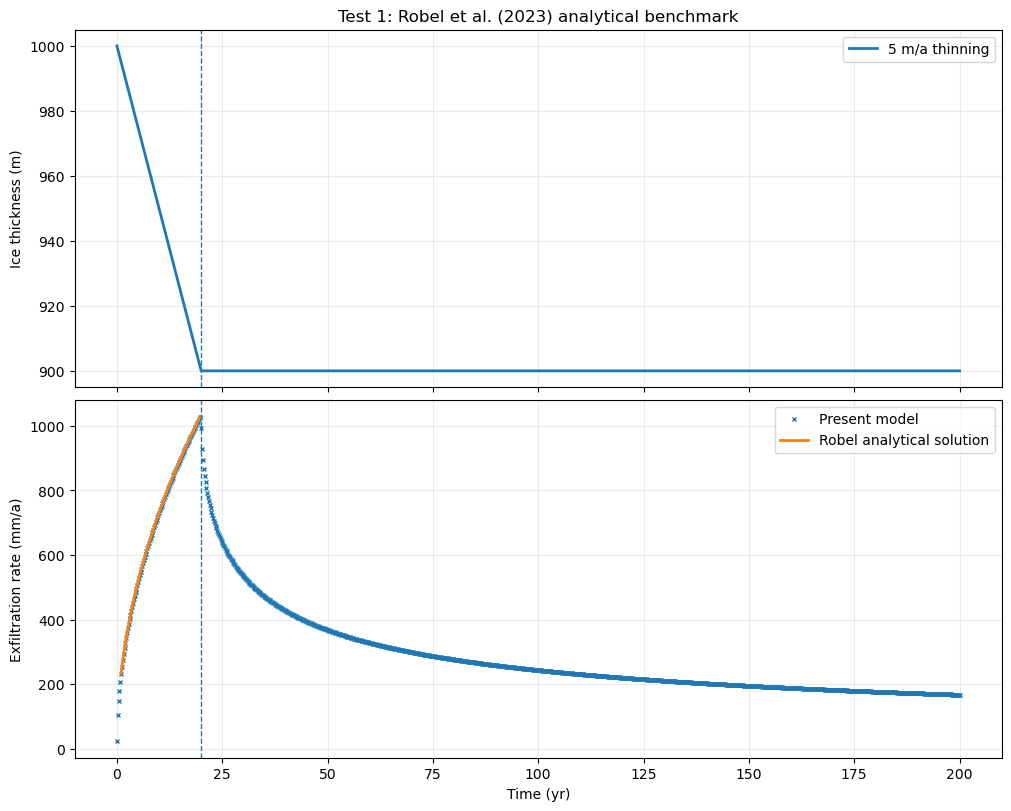

In [7]:
# Test 1: Robel benchmark

# Simple benchmark history
age_test1 = np.array([0.020, 0.0])       # kyr
H_test1 = np.array([1000.0, 900.0])      # m

# Evaluate model for 0–200 years
t_test1 = np.linspace(0.01 * YEAR, 200.0 * YEAR, 1000)

_, q_test1 = exfiltration(age_test1, H_test1, K_t, S, xi, rhoi=rhoi, rhow=rhow, t_eval=t_test1)
q_test1 = to_mm_per_yr(q_test1)

# Robel constant-rate analytical solution
rate_test1 = 5.0 / YEAR

q_robel = (2.0 * (1.0 - xi) * rate_test1 * np.sqrt(t_test1 / tau))
q_robel = to_mm_per_yr(q_robel)

# Compare only during active thinning
active = ((t_test1 / YEAR >= 1.0) & (t_test1 / YEAR <= 20.0))
relative_error = np.abs( q_test1[active] - q_robel[active]) / np.abs(q_robel[active])

print(f"Median relative error: "f"{np.median(relative_error):.3e}")
print(f"Maximum relative error: " f"{np.max(relative_error):.3e}")

# Figure
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

# Loading history
ax[0].plot([0, 20, 200], [1000, 900, 900], linewidth=2, label="5 m/a thinning")
ax[0].axvline(20, linestyle="--", linewidth=1)
ax[0].set_ylabel("Ice thickness (m)")
ax[0].set_title( "Test 1: Robel et al. (2023) analytical benchmark")
ax[0].legend()
ax[0].grid(alpha=0.25)

# Model vs Robel solution
ax[1].plot(t_test1 / YEAR, q_test1, "x", markersize=3, label="Present model")
ax[1].plot(t_test1[active] / YEAR, q_robel[active], linewidth=2, label="Robel analytical solution")
ax[1].axvline(20, linestyle="--", linewidth=1)
ax[1].set_xlabel("Time (yr)")
ax[1].set_ylabel("Exfiltration rate (mm/a)")
ax[1].legend()
ax[1].grid(alpha=0.25)
plt.show()

The model reproduces the Robel analytical solution to numerical precision, with a median relative error of 1.47×10−16 and a maximum relative error of 4.59×10−16. This establishes that the basic analytical response is implemented correctly.

### Test 2

What this tests: whether the interval-superposition method is numerically convergent/discretization-independent -- i.e. whether chopping the *same* continuous thickness history into a different number of intervals changes the predicted exfiltration. This is an internal self-consistency check on the implementation, not a comparison against an independent solution.

This test determines whether the interval-superposition implementation gives the same response when an identical loading history is represented using different numbers of intervals. A 100 m decrease in ice thickness over 20 years is represented using 1, 5, 20, and 100 intervals. Success is demonstrated if changing the number of intervals does not change the calculated response beyond numerical precision.

  1 intervals: maximum relative difference = 0.000e+00
  5 intervals: maximum relative difference = 4.214e-16
 20 intervals: maximum relative difference = 1.427e-15
100 intervals: maximum relative difference = 1.303e-14


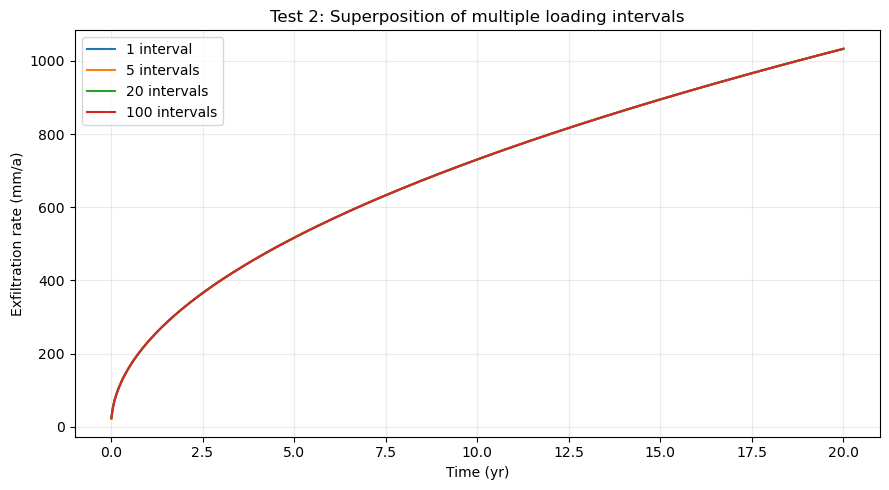

In [8]:
# Test 2: Superposition of multiple loading intervals 

n_intervals = [1, 5, 20, 100]
t_eval = np.linspace(0.01 * YEAR, 20.0 * YEAR, 500)
results = {}

for n in n_intervals:

    # Divide the 20-year loading period into n equal intervals.
    t = np.linspace(0.0, 20.0, n + 1)

    # Ice thickness decreases linearly from 1000 to 900 m.
    H = 1000.0 - 5.0 * t

    # Convert to the age/thickness format used by the model.
    age = (20.0 - t) / 1000.0

    # Run the model.
    _, q = exfiltration(age, H, K_t, S, xi, rhoi=rhoi, rhow=rhow, t_eval=t_eval)
    results[n] = to_mm_per_yr(q)

# Compare every multiple-interval result with the 1-interval solution
q_reference = results[1]

for n in n_intervals:
    relative_error = np.max(
        np.abs(results[n] - q_reference)
        / np.maximum(np.abs(q_reference), 1e-30))
    print(
        f"{n:3d} intervals: "
        f"maximum relative difference = {relative_error:.3e}" )

# Figure 
plt.figure(figsize=(9, 5))

for n in n_intervals:
    plt.plot(
        t_eval / YEAR,
        results[n],
        label=f"{n} interval" if n == 1 else f"{n} intervals" )

plt.xlabel("Time (yr)")
plt.ylabel("Exfiltration rate (mm/a)")
plt.title("Test 2: Superposition of multiple loading intervals")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

All interval representations produce essentially identical responses, with a maximum relative difference of 1.31×10−14 even for 100 intervals. This verifies that the model correctly superposes multiple loading intervals. This is an implementation verification rather than an independent analytical validation.

# Test 3 

What this tests: whether the superposition of two opposing loading events (a retreat immediately reversed by an equal readvance) is handled correctly. Because the net thickness change is zero, the leading-order (sqrt(t)) response should cancel, leaving a weaker, higher-order tail whose decay rate is predicted independently.

This test evaluates the model response to equal and opposite loading changes. Ice thickness decreases by 300 m and subsequently increases by 300 m, giving zero net loading. For this history, the leading t−1/2 response cancels and the independently predicted long-time response is proportional to t−3/2. Success is demonstrated by zero net loading and a modeled long-time slope of approximately −1.5.

Net loading change M0 = 0.0 m
Fitted long-time slope = -1.500


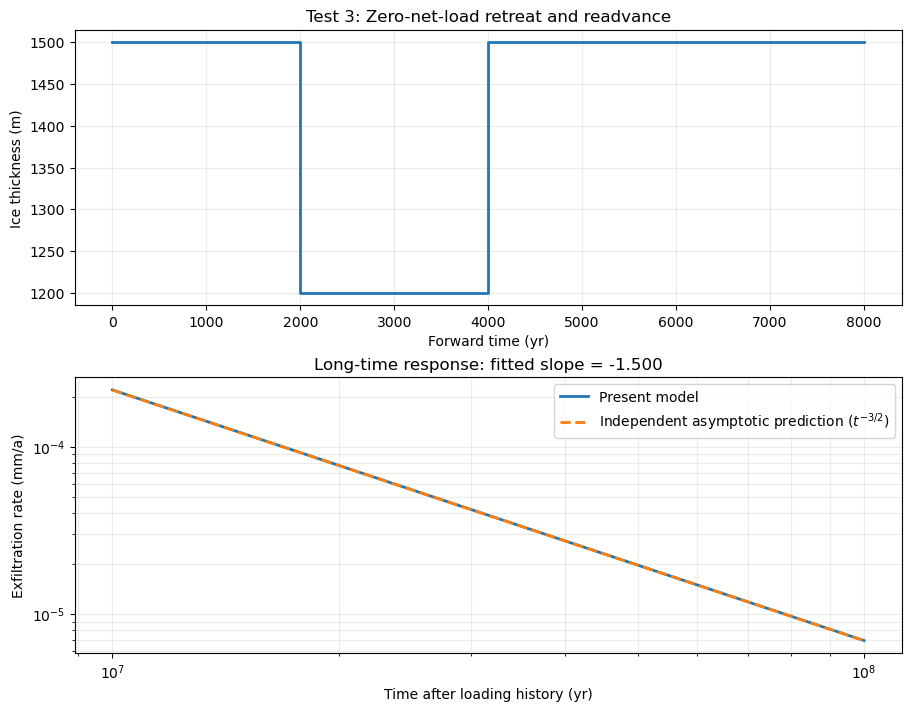

In [9]:
# Test 3: Net-zero load readvance/retreat

# Equal retreat and readvance
age_test3 = np.array([8.0, 6.0, 4.0, 0.0])       # kyr
H_test3   = np.array([1500.0, 1200.0, 1500.0, 1500.0])

# Convert history to forward time
t_hist3, H_hist3, _ = interval_rates(age_test3, H_test3)

# Loading changes
dH = -np.diff(H_hist3)

# Zeroth loading moment: should equal zero
M0 = dH.sum()

# First temporal moment
M1 = (dH * (t_hist3[:-1] + t_hist3[1:]) / 2).sum()

# Evaluate far beyond the loading history
t_test3 = np.logspace(7, 8, 100) * YEAR
_, q_test3 = exfiltration(age_test3,  H_test3, K_t, S, xi, rhoi=rhoi, rhow=rhow, t_eval=t_test3)

# Independent long-time prediction
q_asymptotic = ((1.0 - xi) * M1 / (2.0 * np.sqrt(tau)) * t_test3**(-1.5))

# Fit model slope
slope = np.polyfit( np.log10(t_test3), np.log10(np.abs(q_test3)), 1)[0]

print(f"Net loading change M0 = {M0:.1f} m")
print(f"Fitted long-time slope = {slope:.3f}")

# Figure
fig, ax = plt.subplots(2, 1, figsize=(9, 7),constrained_layout=True)

# Loading history
ax[0].step(t_hist3 / YEAR, H_hist3, where="post", linewidth=2)
ax[0].set_xlabel("Forward time (yr)")
ax[0].set_ylabel("Ice thickness (m)")
ax[0].set_title("Test 3: Zero-net-load retreat and readvance")
ax[0].grid(alpha=0.25)

# Long-time response
ax[1].loglog(t_test3 / YEAR, np.abs(to_mm_per_yr(q_test3)),linewidth=2, label="Present model")
ax[1].loglog(t_test3 / YEAR, np.abs(to_mm_per_yr(q_asymptotic)), "--", linewidth=2, label=r"Independent asymptotic prediction ($t^{-3/2}$)")
ax[1].set_xlabel("Time after loading history (yr)")
ax[1].set_ylabel("Exfiltration rate (mm/a)")
ax[1].set_title(f"Long-time response: fitted slope = {slope:.3f}")
ax[1].legend()
ax[1].grid(alpha=0.25, which="both")
plt.show()

The prescribed retreat and readvance produce zero net loading (M0=0). At long times, the modeled response overlaps the analytical asymptotic prediction and has a fitted log-log slope of −1.500, equal to the theoretical t−3/2 decay. This demonstrates that the model correctly captures the cancellation and long-time response produced by equal and opposite loading events.

# Test 4

What this tests: whether the full interval-superposition scheme can approximate a smooth, continuously oscillating thickness history (rather than a single step or ramp), and whether its accuracy improves as the history is divided into more, smaller intervals -- benchmarked against an independent closed-form (Fresnel-integral) solution for the same continuous forcing.

This test evaluates the complete interval-superposition model against an independent continuous analytical solution for repeated loading and unloading. A sinusoidal ice-thickness history is represented analytically using Fresnel integrals, while the present model approximates the same continuous history using discrete loading intervals. Success is demonstrated if the interval-model solution converges toward the Fresnel solution as the number of intervals increases and the numerical error decreases systematically.

 200 intervals: maximum relative error = 7.163e-03
 800 intervals: maximum relative error = 9.400e-04
3200 intervals: maximum relative error = 1.202e-04

Observed convergence order = 1.47


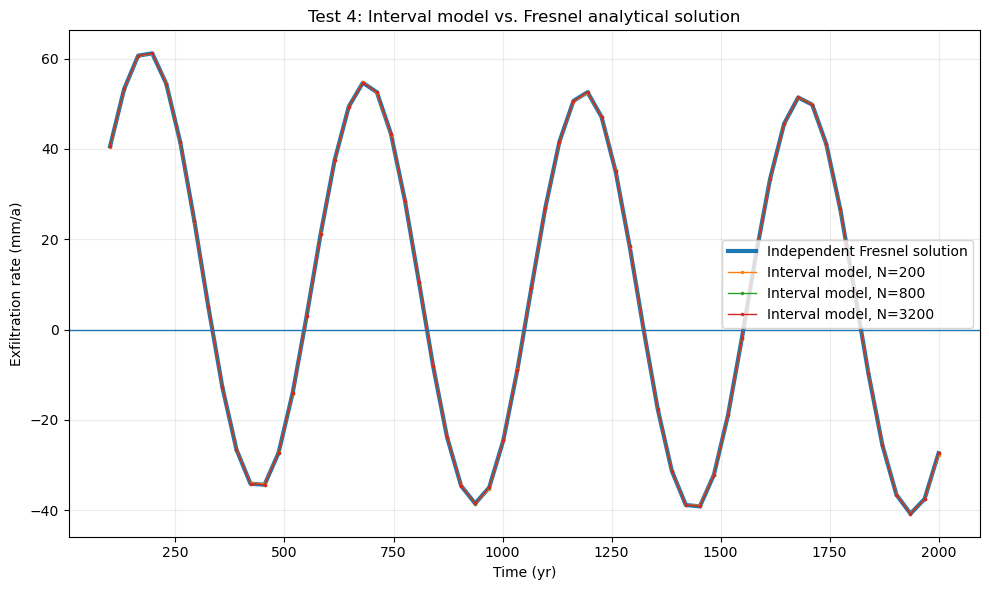

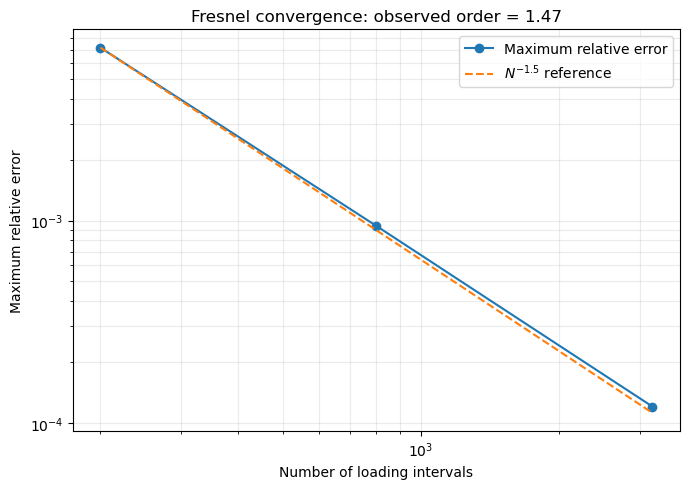

In [10]:
# Test 4: Fresnel analytical solution 

from scipy.special import fresnel

# Sinusoidal loading parameters
r = 4e-9
omega = 2 * np.pi / (500 * YEAR)

# Four complete 500-year retreat/readvance cycles
T = 2000 * YEAR

# Times at which the response is evaluated
t_test4 = np.linspace(0.05, 1.0, 60) * T

# Independent Fresnel solution
S_F, C_F = fresnel(np.sqrt(2 * omega * t_test4 / np.pi))
C_fresnel = (1.0 - xi) / np.sqrt(tau)
q_fresnel = (C_fresnel * r * np.sqrt(2 * np.pi / omega) * ( np.sin(omega * t_test4) * C_F - np.cos(omega * t_test4) * S_F))

# Interval solutions
interval_counts = [200, 800, 3200]
solutions = {}
errors = []

for N in interval_counts:

    # Forward-time nodes
    t_nodes = np.linspace(0, T, N + 1)

    # Continuous sinusoidal ice-thickness history
    H_nodes = (1000.0 + (r / omega) * (np.cos(omega * t_nodes) - 1.0))

    # Convert forward time to age in kyr
    age_nodes = (T - t_nodes) / (1000.0 * YEAR)

    # Run model
    _, q_N = exfiltration(age_nodes, H_nodes, K_t, S, xi, rhoi=rhoi, rhow=rhow, t_eval=t_test4)
    solutions[N] = q_N

    # Relative maximum error
    error = (np.max(np.abs(q_N - q_fresnel)) / np.max(np.abs(q_fresnel)))
    errors.append(error)
    print( f"{N:4d} intervals: " f"maximum relative error = {error:.3e}")

# Convergence
order = (np.log(errors[0] / errors[-1]) / np.log(3200 / 200))
print(f"\nObserved convergence order = {order:.2f}")

# Model versus Fresnel (figure)
plt.figure(figsize=(10, 6))

plt.plot(t_test4 / YEAR, to_mm_per_yr(q_fresnel), linewidth=3, label="Independent Fresnel solution")

for N in interval_counts:
    plt.plot(t_test4 / YEAR, to_mm_per_yr(solutions[N]), ".-", markersize=3, linewidth=1, label=f"Interval model, N={N}")

plt.axhline(0, linewidth=1)
plt.xlabel("Time (yr)")
plt.ylabel("Exfiltration rate (mm/a)")
plt.title("Test 4: Interval model vs. Fresnel analytical solution")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Convergence (figure)
plt.figure(figsize=(7, 5))
plt.loglog(interval_counts, errors, "o-", label="Maximum relative error")

# Reference N^-1.5 convergence slope
N_ref = np.array(interval_counts, dtype=float)
reference = (errors[0] * (N_ref / N_ref[0])**(-1.5))

plt.loglog( N_ref, reference, "--", label=r"$N^{-1.5}$ reference")

plt.xlabel("Number of loading intervals")
plt.ylabel("Maximum relative error")
plt.title( f"Fresnel convergence: observed order = {order:.2f}")
plt.legend()
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()

The interval-model solution converges systematically toward the independent Fresnel analytical solution as the loading history is refined. The maximum relative error decreases from 7.16×10−3 for 200 intervals to 1.20×10−4 for 3200 intervals. The observed convergence order is 1.47, closely matching the expected N−1.5 behavior. The model also reproduces both positive and negative responses throughout repeated loading and unloading cycles. These results demonstrate that the interval-superposition implementation converges to the continuous analytical solution for a time-varying loading history.